In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
random.randint(40,95) # 45부터 90까지 정수중 하나를 무작위 선택 반환

56

In [7]:
data = []
for i in range(50):
    # 여자데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자데이터
    data.append([random.randint(60,95), random.randint(160,195)])
# data

In [8]:
# 여자
for female in data[:100:2]:
    print(female, end=' ')
print('\n---------------------------')
# 남자
for male in data[1:100:2]:
    print(male, end=' ')

[63, 144] [53, 142] [50, 146] [41, 158] [63, 152] [40, 163] [48, 155] [56, 140] [65, 157] [62, 143] [66, 158] [42, 158] [63, 149] [49, 141] [42, 148] [47, 140] [62, 149] [68, 148] [58, 152] [69, 166] [45, 161] [58, 143] [53, 142] [47, 154] [61, 169] [55, 156] [64, 153] [68, 155] [43, 168] [53, 140] [64, 165] [61, 147] [63, 145] [68, 165] [46, 147] [40, 156] [46, 140] [62, 155] [45, 151] [43, 161] [68, 167] [70, 142] [45, 161] [45, 164] [64, 144] [53, 164] [41, 148] [63, 156] [45, 167] [68, 145] 
---------------------------
[63, 188] [95, 186] [91, 173] [75, 171] [62, 169] [81, 165] [69, 168] [70, 168] [67, 183] [92, 168] [87, 171] [93, 167] [65, 164] [83, 173] [88, 176] [75, 163] [81, 160] [68, 165] [86, 175] [92, 187] [81, 183] [64, 189] [67, 162] [64, 188] [87, 188] [73, 183] [60, 163] [89, 178] [73, 176] [87, 172] [69, 165] [74, 175] [76, 165] [84, 168] [71, 185] [72, 163] [95, 176] [90, 184] [77, 163] [89, 193] [73, 190] [81, 195] [80, 174] [82, 165] [70, 168] [64, 174] [78, 193] [

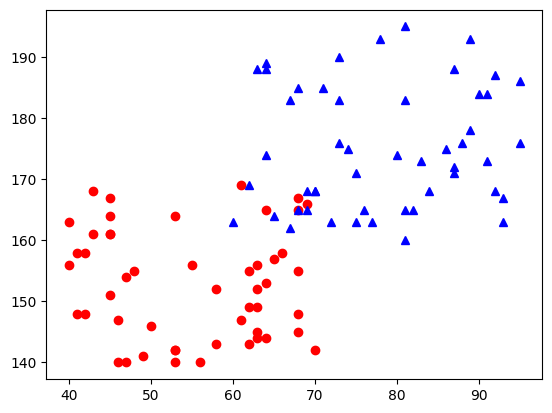

In [11]:
# print('여자 몸무게 :', [d[0] for d in data[::2]])
# print('여자 키 :', [d[1] for d in data[::2]])
# print('남자 몸무게 :', [d[0] for d in data[1::2]])
# print('남자 키 :', [d[1] for d in data[1::2]])

plt.plot([d[0] for d in data[::2]],
        [d[1] for d in data[::2]], 'o', color='r')
plt.plot([d[0] for d in data[1::2]],
        [d[1] for d in data[1::2]], '^', color='b')

# 2. 군집화 로직

In [12]:
# 초기 랜덤지점 4개
random_points = [[random.randint(40,95), random.randint(140,195)],
                [random.randint(40,95), random.randint(140,195)],
                [random.randint(40,95), random.randint(140,195)],
                [random.randint(40,95), random.randint(140,195)]]
random_points

[[52, 165], [61, 162], [94, 190], [80, 180]]

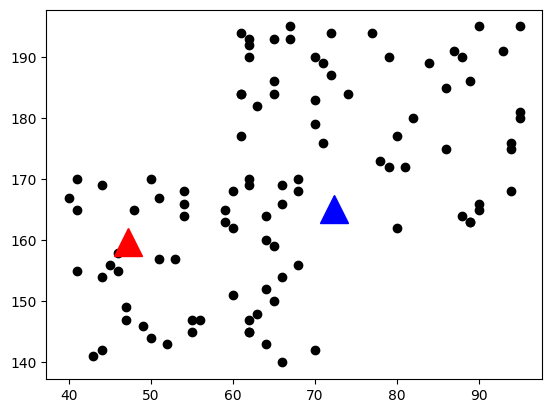

In [34]:
plt.plot([d[0] for d in data],
        [d[1] for d in data], 'o', color='k')
plt.plot(random_points[0][0], random_points[0][1], '^', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0], random_points[1][1], '^', color='b', markersize=20) # 기준점2

In [16]:
# 두 점의 거리를 return a:(0,0) ~ b:(4,3)
def dist(a,b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

In [17]:
a=[0,0]; b=[4,3]
dist(a,b)

5.0

In [35]:
# 두 영역(random_points[0]과 random_points[1]을 기준으로 나눈 두 영역)
group1 = [] # random_points[0]에 가까운 그룹
group2 = [] # random_points[1]에 가까운 그룹

for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group1.append(d)
    else:
        group2.append(d)
len(group1), len(group2)

(33, 67)

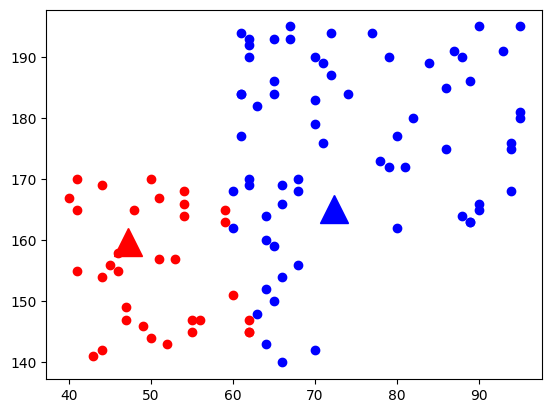

In [36]:
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0], random_points[0][1], '^', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0], random_points[1][1], '^', color='b', markersize=20) # 기준점2
plt.show()

In [37]:
# 기준점 이동 group1의 중심점, group2 중심점
sumX=0; sumY=0
for g in group1:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[0] = [sumX/len(group1), sumY/len(group1)]
sumX=0; sumY=0
for g in group2:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[1] = [sumX/len(group2), sumY/len(group2)]
random_points

[[50.45454545454545, 155.45454545454547],
 [74.25373134328358, 175.47761194029852],
 [94, 190],
 [80, 180]]

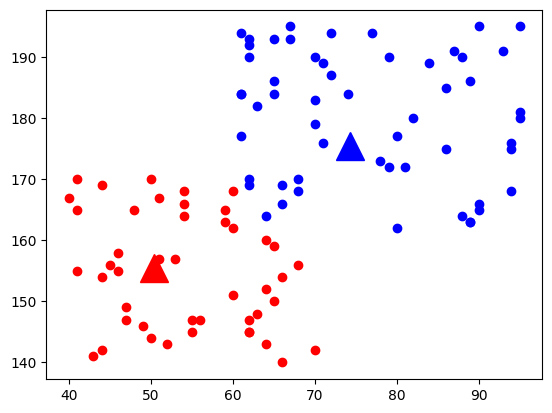

In [38]:
group1 = [] # random_points[0]에 가까운 그룹
group2 = [] # random_points[1]에 가까운 그룹

for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group1.append(d)
    else:
        group2.append(d)
len(group1), len(group2)

plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0], random_points[0][1], '^', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0], random_points[1][1], '^', color='b', markersize=20) # 기준점2
plt.show()

# 3. 전체 코드(for문 이용)
- data 생성
- 랜덤포인트 2지점
- for 문
    - 랜점포인트 2지점 기준으로 group1과 group2
    - 랜덤포인트 이용(group1 중간점, group2중간점)

초기 points :  [[93, 162], [50, 180], [71, 171], [73, 188]]
1 번째 points :  [[88.88888888888889, 171.33333333333334], [57.34375, 166.390625], [75.32, 167.52], [93.5, 191.0]]
2 번째 points :  [[87.0, 174.54545454545453], [58.11267605633803, 163.14084507042253], [76.81818181818181, 176.45454545454547], [87.42857142857143, 188.14285714285714]]
3 번째 points :  [[88.4, 172.1], [57.56716417910448, 161.6417910447761], [75.05555555555556, 181.61111111111111], [89.6, 188.2]]
4 번째 points :  [[85.08333333333333, 169.75], [57.84057971014493, 162.2753623188406], [77.4, 185.46666666666667], [91.75, 186.25]]
5 번째 points :  [[83.0, 168.75], [57.303030303030305, 161.72727272727272], [78.85, 185.15], [92.5, 179.5]]
6 번째 points :  [[81.3, 168.0], [57.046875, 160.984375], [78.30434782608695, 185.0], [91.66666666666667, 174.33333333333334]]
7 번째 points :  [[78.33333333333333, 167.22222222222223], [56.47457627118644, 158.89830508474577], [75.92592592592592, 185.92592592592592], [90.6, 172.2]]
8 번째 points :  [[73.

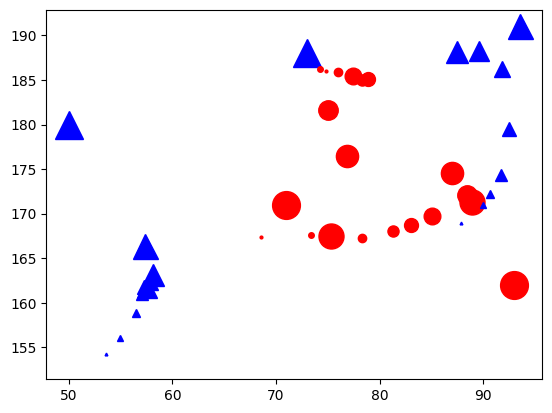

In [64]:
# 데이터 생성
data = []
for i in range(50):
    # 여자데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자데이터
    data.append([random.randint(60,95), random.randint(160,195)])
#point 지정
points = [[random.randint(40,95), random.randint(140,195)],
                [random.randint(40,95), random.randint(140,195)],
                [random.randint(40,95), random.randint(140,195)],
                [random.randint(40,95), random.randint(140,195)]]
print('초기 points : ', points)
plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=20) # 기준점1
plt.plot(points[1][0], points[1][1], '^', color='b', markersize=20) # 기준점2
plt.plot(points[2][0], points[2][1], 'o', color='r', markersize=20) # 기준점3
plt.plot(points[3][0], points[3][1], '^', color='b', markersize=20) # 기준점4
# 포인트 2지점 기준을 group1과 group2
for i in range(1, 11):
    group1= [] # 1에 가까운 그룹
    group2= [] # 2에 가까운 그룹
    group3= [] # 3에 가까운 그룹
    group4= [] # 4에 가까운 그룹
    for d in data:
        if dist(d, points[0]) < dist(d, points[1]):
            if dist(d, points[0]) < dist(d, points[2]):
                if dist(d, points[0]) < dist(d, points[3]):
                    group1.append(d)
                else:
                    group4.append(d)
            else:
                group3.append(d)
        else:
            group2.append(d)
    sumX=0; sumY=0
    for g in group1:
        sumX += g[0]
        sumY += g[1]
    # 새로운 기준점으로 할당
    points[0] = [sumX/len(group1), sumY/len(group1)]
    sumX=0; sumY=0
    for g in group2:
        sumX += g[0]
        sumY += g[1]
    # 새로운 기준점으로 할당
    points[1] = [sumX/len(group2), sumY/len(group2)]
    sumX=0; sumY=0
    for g in group3:
        sumX += g[0]
        sumY += g[1]
    # 새로운 기준점으로 할당
    points[2] = [sumX/len(group3), sumY/len(group3)]
    sumX=0; sumY=0
    for g in group4:
        sumX += g[0]
        sumY += g[1]
    # 새로운 기준점으로 할당
    points[3] = [sumX/len(group4), sumY/len(group4)]
    
    print(i,'번째 points : ', points)
    plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=20-i*2) # 기준점1
    plt.plot(points[1][0], points[1][1], '^', color='b', markersize=20-i*2) # 기준점2
    plt.plot(points[2][0], points[2][1], 'o', color='r', markersize=20-i*2) # 기준점1
    plt.plot(points[3][0], points[3][1], '^', color='b', markersize=20-i*2) # 기준점2

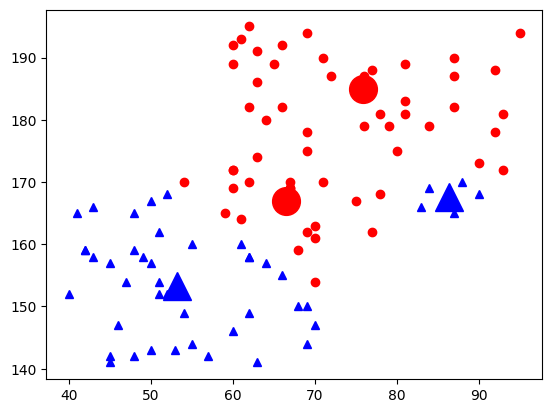

In [65]:
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], '^', color='b')
plt.plot([d[0] for d in group3],
        [d[1] for d in group3], 'o', color='r')
plt.plot([d[0] for d in group4],
        [d[1] for d in group4], '^', color='b')
plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=20) # 기준점1
plt.plot(points[1][0], points[1][1], '^', color='b', markersize=20) # 기준점2
plt.plot(points[2][0], points[2][1], 'o', color='r', markersize=20) # 기준점3
plt.plot(points[3][0], points[3][1], '^', color='b', markersize=20) # 기준점4

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝
    * 예측모델
        : 분류, 회귀, 군집분석
            fit(학습), predict(예측)
    * 변환함수
        : 전처리 ex. 스케일 조정
            fit(학습), transform(변환함수)

In [40]:
# 군집분석 라이브러리가 joblib 충돌 경고 메세지 출력
import os
os.environ['OMP_NUM_THREADS'] = '1'

In [43]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 2개 그룹으로 나눠
              init='random', # 초기 중심점 랜덤하게
              n_init=10, # 10번 실행
              random_state=7)
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [44]:
# 중심점
model.cluster_centers_

array([[ 77.37254902, 181.45098039],
       [ 54.97959184, 155.7755102 ]])

In [46]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [50]:
group1 = data[model.labels_==1]
group2 = data[model.labels_==0]
c1, c2 = model.cluster_centers_

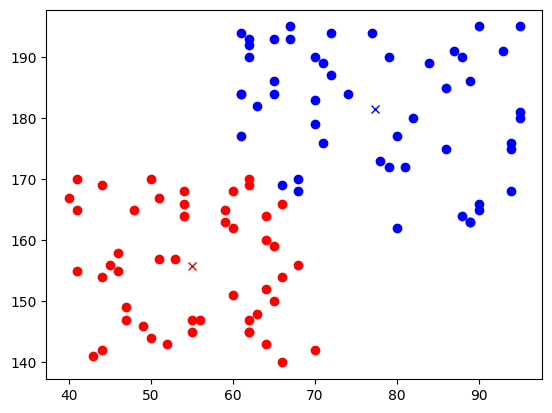

In [52]:
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(c1[0], c1[1], 'x', color='b') # g2의 중심점
plt.plot(c2[0], c2[1], 'x', color='r') # g1의 중심점